In [1]:
import os, re
from pathlib import Path
import nrrd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.patches as mpatches
from typing import List, Dict, Tuple, Optional
from scipy.ndimage import percentile_filter
from tqdm import tqdm

**Goal:** Identification of significantly activated or inhibited brain regions during stimulus treatment  
**Idea:** Bootstrapped null distribution used to determine 95% Confidence Interval; regions with observed mean outside these bounds are significant  

**Principal Procedure:**
1. data preparation
2. calculate true/observed statistics
3. bootstrap null distribution
4. use 95% CIs from bootstrap distribution to determine significant regions

**Metric used here:** 
- log2(mean stimulus / mean habituation) of the fluorescence traces, because log2 preserves symmetry around zero
- computed twice: on the raw fluorescence traces and the detrended traces
- tested against a single bootstrap null distribution of the overall regional mean (permutation of neuron to region labels within each fish)

**Basic Parameter Settings**

In [2]:
data_path = '/Volumes/raid_126TB//Mikrofluidik/2025/aligned_ants_selected'
reference_brain = 'zbrain'  # zbrain or mapzebrain
region_names_excel = f'{data_path}/Region_names_{reference_brain}.xlsx'  # Include column and short names

baseline_frames = (90, 180)  # 90 frames approximately 5 min; half of habituation as baseline
habituation = [slice(*baseline_frames)]
stimulus = [slice(185, 370), slice(647, 832)]  # combine the two stimulus phases for analysis

min_cells = 20     # min neurons per fish and region to be considered
n_boot = 10000     # bootstrap iterations: 10,000 for the manuscript statistics (1,000 ~ 10 min for a test run)

**Metric functions**

In [3]:
def mean_over_slices(df: pd.DataFrame, slices):

    parts = [df.iloc[:, slc] for slc in slices]
    if len(parts) == 1:
        return parts[0].mean(axis=1)
    cat = pd.concat(parts, axis=1)
    return cat.mean(axis=1)


In [4]:
def compute_log2fc(
    traces_df: pd.DataFrame,
    pre_slices,
    post_slices,
    eps: float=1e-6) -> pd.Series:

    # compute mean over selected timespans
    pre_mean  = mean_over_slices(traces_df, pre_slices)
    post_mean = mean_over_slices(traces_df, post_slices)
    
    # Ensure strictly positive for log_ratio
    pre_safe  = np.clip(pre_mean.values,  eps, None)
    post_safe = np.clip(post_mean.values, eps, None)

    log2fc = np.log2(post_safe / pre_safe)
    
    return pd.Series(log2fc, index=traces_df.index, name="metric")


**Loading and preparation of the data**

In [5]:
region_names = pd.read_excel(region_names_excel, sheet_name='Sheet1', header=0)
included_regions = set(region_names.loc[region_names['Include'], 'Original Names'])

In [6]:
def load_fluorescence_one_fish(fish_number, compound, folder, reference_brain, detrended):

    traces_csv = folder / f"{fish_number}_{compound}_traces_included_regions_{reference_brain}.csv"
    traces = pd.read_csv(traces_csv, index_col=0)
    if not detrended:
        return traces

    dff_csv = folder / f"{fish_number}_{compound}_dFF_included_regions_{reference_brain}_detrended.csv"
    dff = pd.read_csv(dff_csv, index_col=0).reindex(traces.index)

    F = traces.to_numpy(dtype=float)
    b0, b1 = baseline_frames
    F0 = F[:, b0:min(b1, F.shape[1])].mean(axis=1)
    F0 = np.where(F0 == 0, np.nan, F0)
    F_corr = F0[:, None] * (1.0 + dff.to_numpy(dtype=float))   # detrended fluorescence trace
    
    return pd.DataFrame(F_corr, index=traces.index, columns=traces.columns)
    

In [7]:
def load_all_fish_and_compute_log2fc(root, compound, reference_brain, pre_slices, post_slices, detrended):
    
    folder = root / "neurons" / "analysis"
    all_long = []
    pattern = rf"{compound}_cells_included_regions_{reference_brain}.csv"
    
    for file in sorted(os.listdir(folder)):
        if re.search(pattern, file):
            fish_number = file.split('_')[0]
            print(f"  {fish_number} ({'detrended' if detrended else 'raw'})")

            fluor  = load_fluorescence_one_fish(fish_number, compound, folder, reference_brain, detrended)
            metric = compute_log2fc(fluor, pre_slices, post_slices)

            cells = pd.read_csv(folder / f"{fish_number}_{compound}_cells_included_regions_{reference_brain}.csv",
                                index_col=0).reindex(fluor.index)
            non_region_cols = {"x", "y", "z", "t", "label"}
            region_cols = [c for c in cells.columns if c not in non_region_cols and c in included_regions]

            cells = cells.copy()
            cells["neuron_id"] = np.arange(len(cells))
            long = (cells[["neuron_id"] + region_cols]
                    .melt(id_vars="neuron_id", var_name="region", value_name="in_region")
                    .query("in_region == True").drop(columns="in_region"))
            long = long.merge(pd.DataFrame({"neuron_id": np.arange(len(cells)), "metric": metric.values}),
                              on="neuron_id", how="left")
            long["fish_id"] = fish_number
            long["group"]   = compound
            all_long.append(long[["fish_id", "group", "neuron_id", "region", "metric"]])

    if not all_long:
        raise RuntimeError(f"No fish found for {compound} in {folder}")
        
    return pd.concat(all_long, ignore_index=True).dropna(subset=["metric"])
    

**True per region summaries across fish**

In [8]:
def per_fish_mean_table(
    df_long: pd.DataFrame, 
    group: str, 
    value_col: str = "metric", 
    min_cells: int = 20):

    df = df_long.query("group == @group")
    regions = sorted(df["region"].unique())
    fish_ids = df["fish_id"].unique().tolist()
    
    mean_fish = pd.DataFrame(index=regions, columns=fish_ids, dtype=float)
    
    for (region, fish_id), group in df.groupby(["region", "fish_id"], sort=False):
        vals = group[value_col].values
        if len(vals) < min_cells:
            continue
        mean_fish.loc[region, fish_id] = np.mean(vals)
        
    return mean_fish


In [9]:
def summarize_across_fish(tbl: pd.DataFrame):

    mean = tbl.mean(axis=1, skipna=True)
    sd   = tbl.std(axis=1, ddof=1, skipna=True)
    n    = tbl.notna().count(axis=1)
    return mean, sd, n

**Bootstrap null distribution by shuffling region labels within each fish**

In [10]:
def bootstrap_null_overall_mean(
    df_long: pd.DataFrame, 
    group: str,
    value_col: str = "metric",
    min_cells=20, 
    n_boot=10000, 
    random_state=1):

    rng = np.random.default_rng(random_state)
    df = df_long.query("group == @group").copy()
    regions = sorted(df["region"].unique())

    fish_tables = [
        g[["region", value_col]].reset_index(drop=True) 
        for _, g in df.groupby("fish_id", sort=False)]
    
    boot_mean = pd.DataFrame(index=regions, columns=np.arange(n_boot), dtype=float)

    for b in tqdm(range(n_boot)):
        per_fish_means = {}
        
        for g_fish in fish_tables:
            labels = g_fish["region"].to_numpy()
            shuf = labels.copy()
            rng.shuffle(shuf)
            tmp = g_fish.copy()
            tmp["region_shuf"] = shuf
            
            for reg, g in tmp.groupby("region_shuf", sort=False):
                vals = g[value_col].to_numpy()
                if len(vals) < min_cells:
                    continue
                per_fish_means.setdefault(reg, []).append(np.mean(vals))
        
        for reg in regions:
            boot_mean.loc[reg, b] = np.mean(per_fish_means.get(reg, [np.nan]))
    
    # Single CI for the null distribution
    null_mean = boot_mean.mean(axis=1, skipna=True)
    null_ci_low  = boot_mean.quantile(0.025, axis=1, interpolation="linear")
    null_ci_high = boot_mean.quantile(0.975, axis=1, interpolation="linear")

    null_summary_mean = pd.DataFrame({
        "null_mean_mean": null_mean,
        "null_mean_ci_low": null_ci_low,
        "null_mean_ci_high": null_ci_high,
    }).sort_index()

    return boot_mean, null_summary_mean


**Determine confidence intervals by comparing true region summaries with bootstrapped null distributions**

In [11]:
def build_results_single_null_mean(
    df_long: pd.DataFrame, 
    group: str, 
    value_col: str = "metric", 
    min_cells: int = 1, 
    n_boot: int = 10000, 
    random_state: int = 1):
    # true overall mean
    mean_fish = per_fish_mean_table(df_long, group, value_col, min_cells)
    true_mean, sd, n = summarize_across_fish(mean_fish)

    # single null distribution via bootstrap
    _, null_sum_mean = bootstrap_null_overall_mean(df_long, group, value_col, min_cells, n_boot, random_state)

    # combine results
    res = pd.concat([
        true_mean.rename("true_mean"),
        sd.rename("sd"),
        n.rename("n"),
        null_sum_mean
    ], axis=1).sort_index()

    # determine significance
    res["upregulated"]   = res["true_mean"] > res["null_mean_ci_high"]
    res["downregulated"] = res["true_mean"] < res["null_mean_ci_low"]
    
    return res

**Plotting**

In [12]:
# Anatomical ordering
region_info = pd.read_excel('/Volumes/raid_126TB/H2B_GCaMP6s_new/Region_names_zbrain.xlsx', sheet_name='Sheet1', header=0)

division_order  = ['Telencephalon', 'Diencephalon', 'Mesencephalon', 'Rhombencephalon']
division_colors = {'Telencephalon': 'tab:red',  'Diencephalon': 'orange',
                   'Mesencephalon': 'mediumseagreen', 'Rhombencephalon': 'dodgerblue'}

short_name_map   = dict(zip(region_info['Original Names'], region_info['Short Names']))
region_row_order = {name: i for i, name in enumerate(region_info['Original Names'])}


In [13]:
def get_division(region):
    s = str(region).strip()
    for d in division_order:
        if s.startswith(d):
            return d
    return s.split(' - ')[0].strip()

In [14]:
def division_color(region):
    return division_colors.get(get_division(region), 'gray')

In [15]:
def anatomical_sort_key(region):
    div   = get_division(region)
    drank = division_order.index(div) if div in division_order else len(division_order)
    return (drank, region_row_order.get(region, 10**6), str(region))

In [16]:
# Z-Brain reference and region masks

zbrain_reference   = '/Users/koester_lab/Documents/Z-Brain/Elavl3-H2BRFP_z_brain.nrrd'
zbrain_masks = '/Users/koester_lab/Documents/Z-Brain/z_brain_regions'

def load_nrrd(path):
    vol, header = nrrd.read(path)
    return np.asarray(vol).T, header

def project_max(vol, axis=0):   # axis=0 is the z-axis after the transpose
    return np.max(vol, axis=axis)

ref_vol, _ = load_nrrd(zbrain_reference)
ref_proj   = project_max(ref_vol)

# Shift slightly so the masks line up (same as in Average Activity Traces):
w = ref_proj.shape[1]
black = np.zeros((ref_proj.shape[0], 10), dtype=ref_proj.dtype)
reference_concat = np.concatenate((black, ref_proj[:, 0:w - 10]), axis=1)
reference_concat.shape

(1406, 621)

In [17]:
mask_proj_cache = {}
def region_mask_projection(region):

    if region in mask_proj_cache:
        return mask_proj_cache[region]
    path = os.path.join(zbrain_masks, f"{region}.nrrd")
    if not os.path.exists(path):
        mask_proj_cache[region] = None
        return None
    vol, _ = load_nrrd(path)
    mask_proj_cache[region] = project_max(vol > 0).astype(bool)
    return mask_proj_cache[region]
    

In [18]:
# Region significance bar chart
def plot_bootstrap_anatomical(results, xlabel, path_to_save,
                              selected_regions=None, xlim=None, draw_brain=True,
                              brain_alpha=0.5):

    up_color, down_color = 'firebrick', 'steelblue'

    res = results.copy()
    sig = res[(res['upregulated']) | (res['downregulated'])]
    if selected_regions is not None:
        sig = sig.loc[sig.index.intersection(selected_regions)]
    if sig.empty:
        print('No significant regions to plot.'); return None

    up   = sorted([r for r in sig.index if bool(sig.loc[r, 'upregulated'])],   key=anatomical_sort_key)
    down = sorted([r for r in sig.index if bool(sig.loc[r, 'downregulated'])], key=anatomical_sort_key)
    regions = up + down  # up first: after invert_yaxis it sits in the upper half
    n_up = len(up)
    up_set = set(up)
    y = np.arange(len(regions))

    vals   = res.loc[regions, 'true_mean'].to_numpy(float)
    sd     = res.loc[regions, 'sd'].fillna(0).to_numpy(float)
    nlow   = res.loc[regions, 'null_mean_ci_low'].to_numpy(float)
    nhigh  = res.loc[regions, 'null_mean_ci_high'].to_numpy(float)
    div_colors = [division_color(r) for r in regions]                        # anatomy strip / legend
    dir_colors = [up_color if r in up_set else down_color for r in regions]  # bars / brain: by direction
    labels = [short_name_map.get(r, r) for r in regions]

    # one-sided error bars pointing away from 0
    lower = np.where(vals < 0, sd, 0.0)
    upper = np.where(vals > 0, sd, 0.0)
    xerr  = np.vstack([lower, upper])

    # layout: labels + thin anatomy strip + bars + brain map
    height = max(3.0, 0.32 * len(regions))
    if draw_brain:
        fig = plt.figure(figsize=(12, height))
        gs = fig.add_gridspec(1, 3, width_ratios=[0.1, 4.0, 3.2], wspace=0)
        ax_side  = fig.add_subplot(gs[0, 0])
        ax       = fig.add_subplot(gs[0, 1], sharey=ax_side)
        ax_brain = fig.add_subplot(gs[0, 2])
    else:
        fig = plt.figure(figsize=(8, height))
        gs = fig.add_gridspec(1, 2, width_ratios=[0.1, 4.0], wspace=0)
        ax_side  = fig.add_subplot(gs[0, 0])
        ax       = fig.add_subplot(gs[0, 1], sharey=ax_side)
        ax_brain = None

    # anatomy: black labels + a thin division-colored strip
    ax_side.barh(y, np.ones(len(regions)), left=0, height=1.0, color=div_colors, edgecolor='none')
    ax_side.set_xlim(0, 1)
    ax_side.margins(x=0)
    ax_side.set_yticks(y)
    ax_side.set_yticklabels(labels, fontsize=14, color='black')
    ax_side.set_xticks([])
    for s in ('top', 'right', 'bottom', 'left'):
        ax_side.spines[s].set_visible(False)
    ax_side.tick_params(length=0)

    # main bars (red=up / blue=down) + null CI band
    ax.fill_betweenx(y, nlow, nhigh, color='lightgray', alpha=0.6, zorder=0)
    ax.plot(nlow,  y, color='dimgray', lw=0.8, alpha=0.9)
    ax.plot(nhigh, y, color='dimgray', lw=0.8, alpha=0.9)
    ax.barh(y, vals, height=0.6, color=dir_colors, edgecolor='black', linewidth=0.5, alpha=0.97, zorder=3)
    ax.errorbar(vals, y, xerr=xerr, fmt='none', ecolor='black', elinewidth=1.0, capsize=2, zorder=4)
    ax.axvline(0, color='black', lw=0.8)

    # divider + half labels (up on top, down on bottom)
    if 0 < n_up < len(regions):
        ax.axhline(n_up - 0.5, color='black', lw=0.8, ls='--', alpha=0.7)
    ax.text(0.98, 0.995, 'upregulated',   transform=ax.transAxes, ha='right', va='top',
            fontsize=14, color=up_color)
    ax.text(0.98, 0.005, 'downregulated', transform=ax.transAxes, ha='right', va='bottom',
            fontsize=14, color=down_color)

    ax.set_ylim(-0.5, len(regions) - 0.5)
    ax.invert_yaxis()
    plt.setp(ax.get_yticklabels(), visible=False)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', labelsize=14)
    if xlim is not None:
        ax.set_xlim(-xlim, xlim)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # anatomy-division key (explains the thin colored strip)
    divs_present = [d for d in division_order if any(get_division(r) == d for r in regions)]
    handles = [mpatches.Patch(color=division_colors[d], label=d) for d in divs_present]

    # Z-Brain projection: selected regions filled red (up) / blue (down), with alpha
    if ax_brain is not None:
        ax_brain.imshow(reference_concat, cmap='gray', interpolation='nearest')
        for r in regions:
            proj = region_mask_projection(r)
            if proj is None:
                continue
            c = up_color if r in up_set else down_color
            ax_brain.contourf(proj.astype(float), levels=[0.5, 1.5], colors=[c], alpha=brain_alpha)
        ax_brain.set_axis_off()
        ax_brain.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.0, 1.0),
                        fontsize=12, frameon=False)

    fig.savefig(path_to_save, bbox_inches='tight', pad_inches=0.2)
    return fig

**Optional: only plot a selection of regions**

In [19]:
# Set True and edit the list to restrict the figures to the chosen regions; set False to show all significantly modified regions
use_curated_selection = False

selected_regions = [
    "Telencephalon - ",
    "Telencephalon - Olfactory Bulb",
    "Telencephalon - Pallium",
    "Telencephalon - Subpallium",
    "Telencephalon - Subpallial dopaminergic cluster",
    "Telencephalon - Subpallial Gad1b cluster",
    "Telencephalon - Subpallial Otpb Cluster 2",
    "Telencephalon - Vmat2 cluster",
    "Diencephalon - ",
    "Diencephalon - Habenula",
    "Diencephalon - Left Habenula Vglut2 cluster",
    "Diencephalon - Right Habenula Vglut2 cluster",
    "Diencephalon - Dopaminergic Cluster 1 - ventral thalamic and periventricular posterior tubercular DA neurons",
    "Diencephalon - Otpb Cluster 2",
    "Diencephalon - Oxtl Cluster 1 in Preoptic Area",
    "Diencephalon - Pineal",
    "Diencephalon - Posterior Tuberculum",
    "Diencephalon - Preoptic Area",
    "Diencephalon - Ventral Thalamus",
    "Mesencephalon - ",
    "Mesencephalon - Tecum Neuropil",
    "Mesencephalon - Tectum Stratum Periventriculare",
    "Mesencephalon - Tegmentum",
    "Mesencephalon - Torus Longitudinalis",
    "Rhombencephalon - ",
    "Rhombencephalon - Cerebellum",
    "Rhombencephalon - Cerebellar Neuropil 1",
    "Rhombencephalon - Cerebellum Gad1b Enriched Areas",
    "Rhombencephalon - Cereblluar-Vglut2 enriched areas",
    "Rhombencephalon - Corpus Cerebelli",
    "Rhombencephalon - Olig2 enriched areas in cerebellum",
    "Rhombencephalon - Olig2 cluster",
    "Rhombencephalon - Locus Coreuleus",
    "Rhombencephalon - Otpb Cluster 2 - locus coeruleus",
    "Rhombencephalon - Rhombomere 1"
]

**Produce figures and csv files for selected compounds, both raw and detrended**

In [20]:
root  = Path(data_path)
outdir = f'{data_path}/neurons/analysis/bootstrap_analysis'
os.makedirs(outdir, exist_ok=True)

compounds = ['control', 'PTZ', 'Tricaine']

In [21]:
if use_curated_selection:
    curated = selected_regions
    draw_brain = True
    selected = 'selected'
else:
    curated = None
    draw_brain = False
    selected = 'all'


 control | raw
  fish01 (raw)
  fish02 (raw)
  fish04 (raw)
  fish06 (raw)
  fish09 (raw)


100%|█████████████████████████████████████| 10000/10000 [20:02<00:00,  8.31it/s]


  -> 112 significant regions  (58 up / 54 down)

 control | detrended
  fish01 (detrended)
  fish02 (detrended)
  fish04 (detrended)
  fish06 (detrended)
  fish09 (detrended)


100%|█████████████████████████████████████| 10000/10000 [21:01<00:00,  7.93it/s]


  -> 99 significant regions  (62 up / 37 down)

 PTZ | raw
  fish04 (raw)
  fish08 (raw)
  fish09 (raw)
  fish11 (raw)
  fish12 (raw)


...

  -> 147 significant regions  (72 up / 75 down)

 Tricaine | raw
  fish02 (raw)
  fish04 (raw)
  fish06 (raw)
  fish07 (raw)
  fish10 (raw)


100%|█████████████████████████████████████| 10000/10000 [22:39<00:00,  7.36it/s]


  -> 130 significant regions  (69 up / 61 down)

 Tricaine | detrended
  fish02 (detrended)
  fish04 (detrended)
  fish06 (detrended)
  fish07 (detrended)
  fish10 (detrended)


100%|█████████████████████████████████████| 10000/10000 [21:42<00:00,  7.68it/s]


  -> 129 significant regions  (66 up / 63 down)


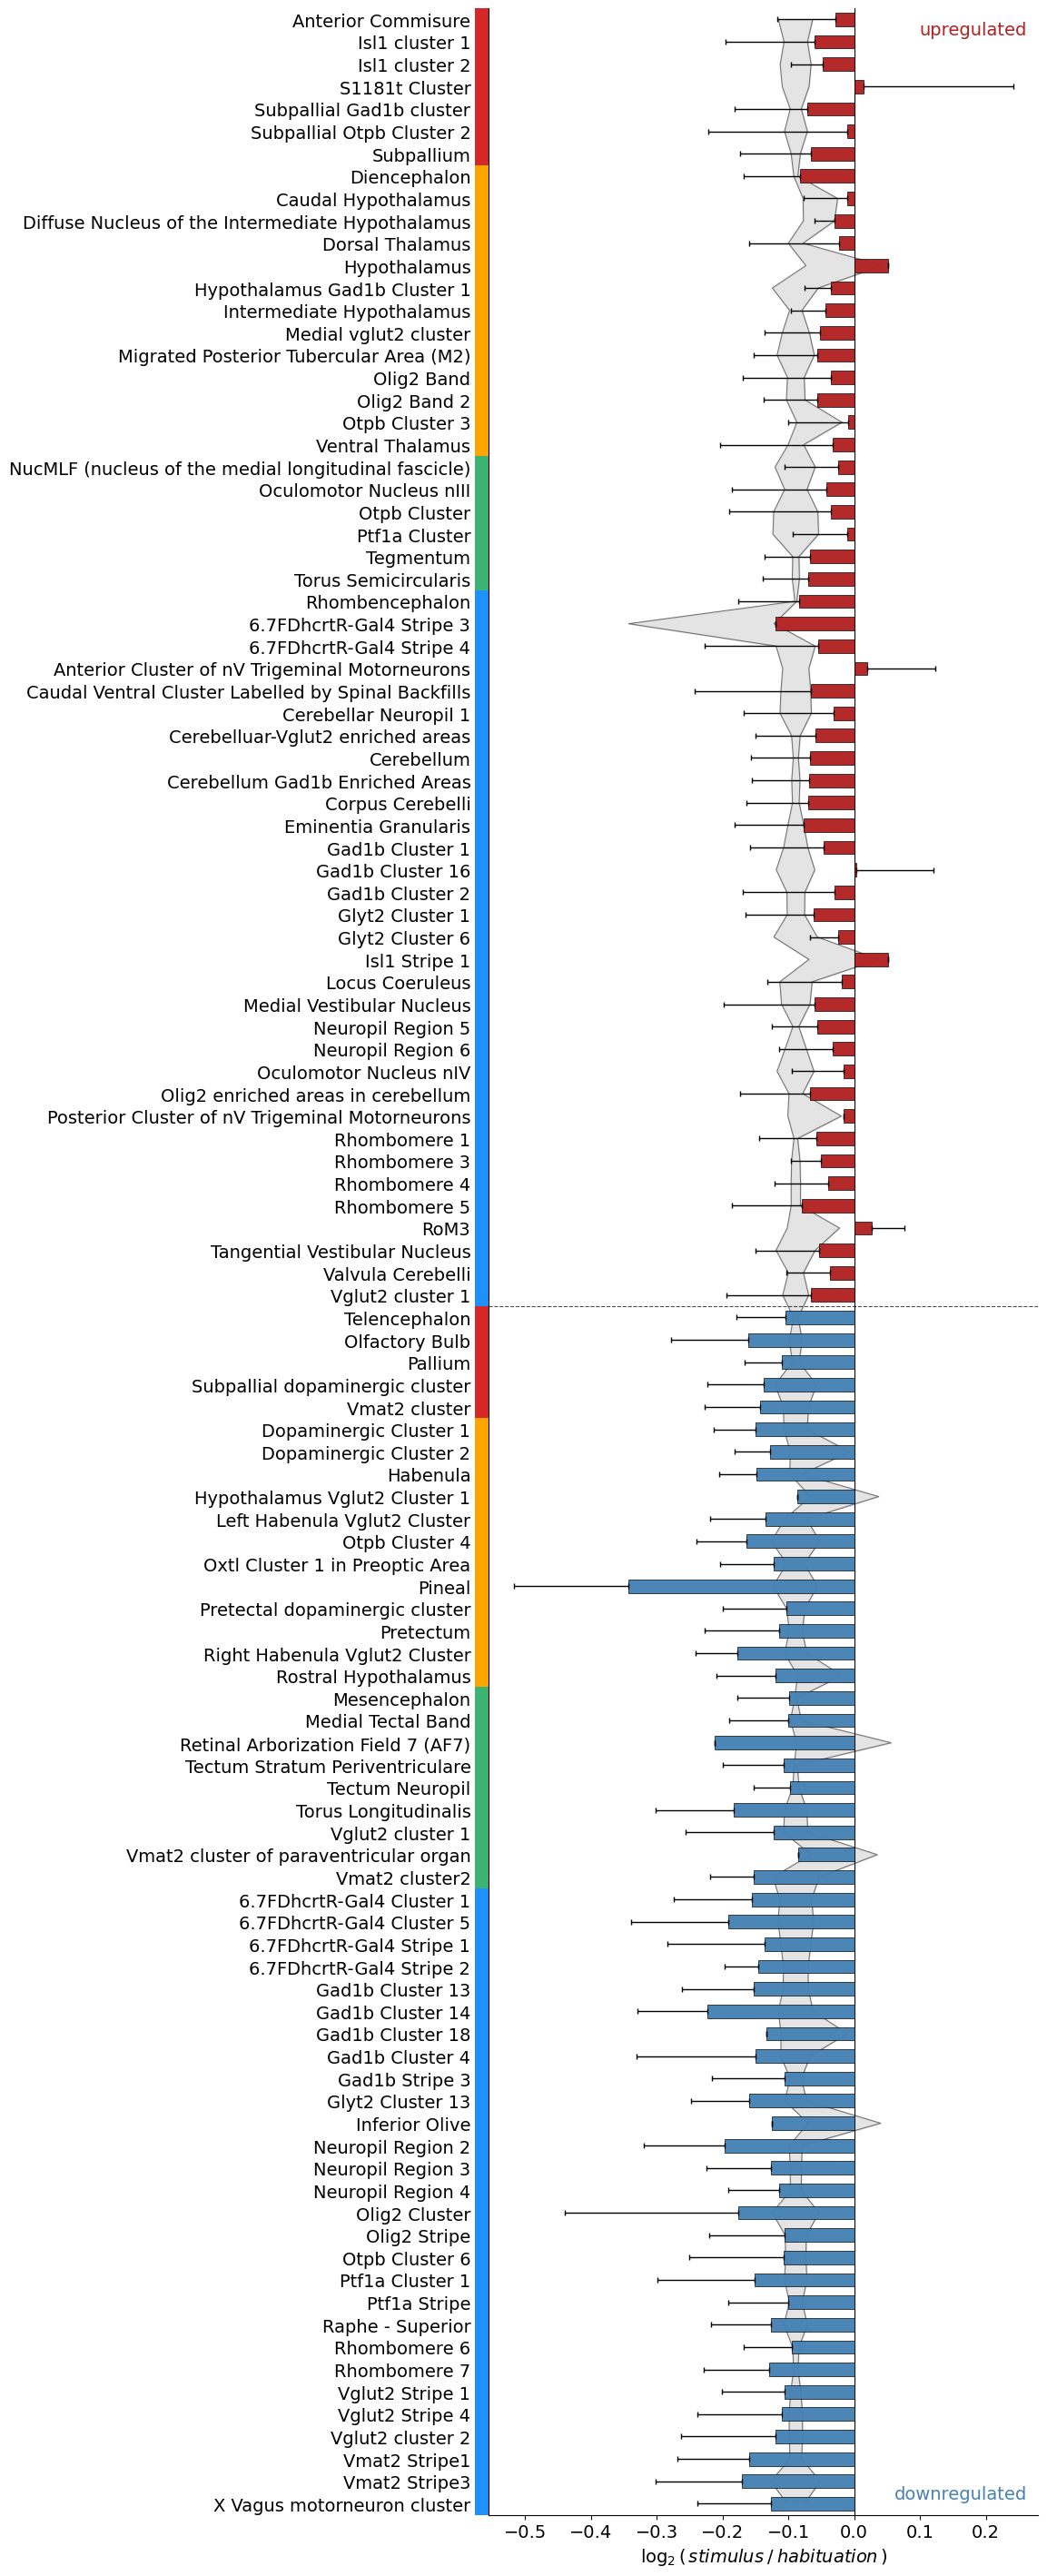

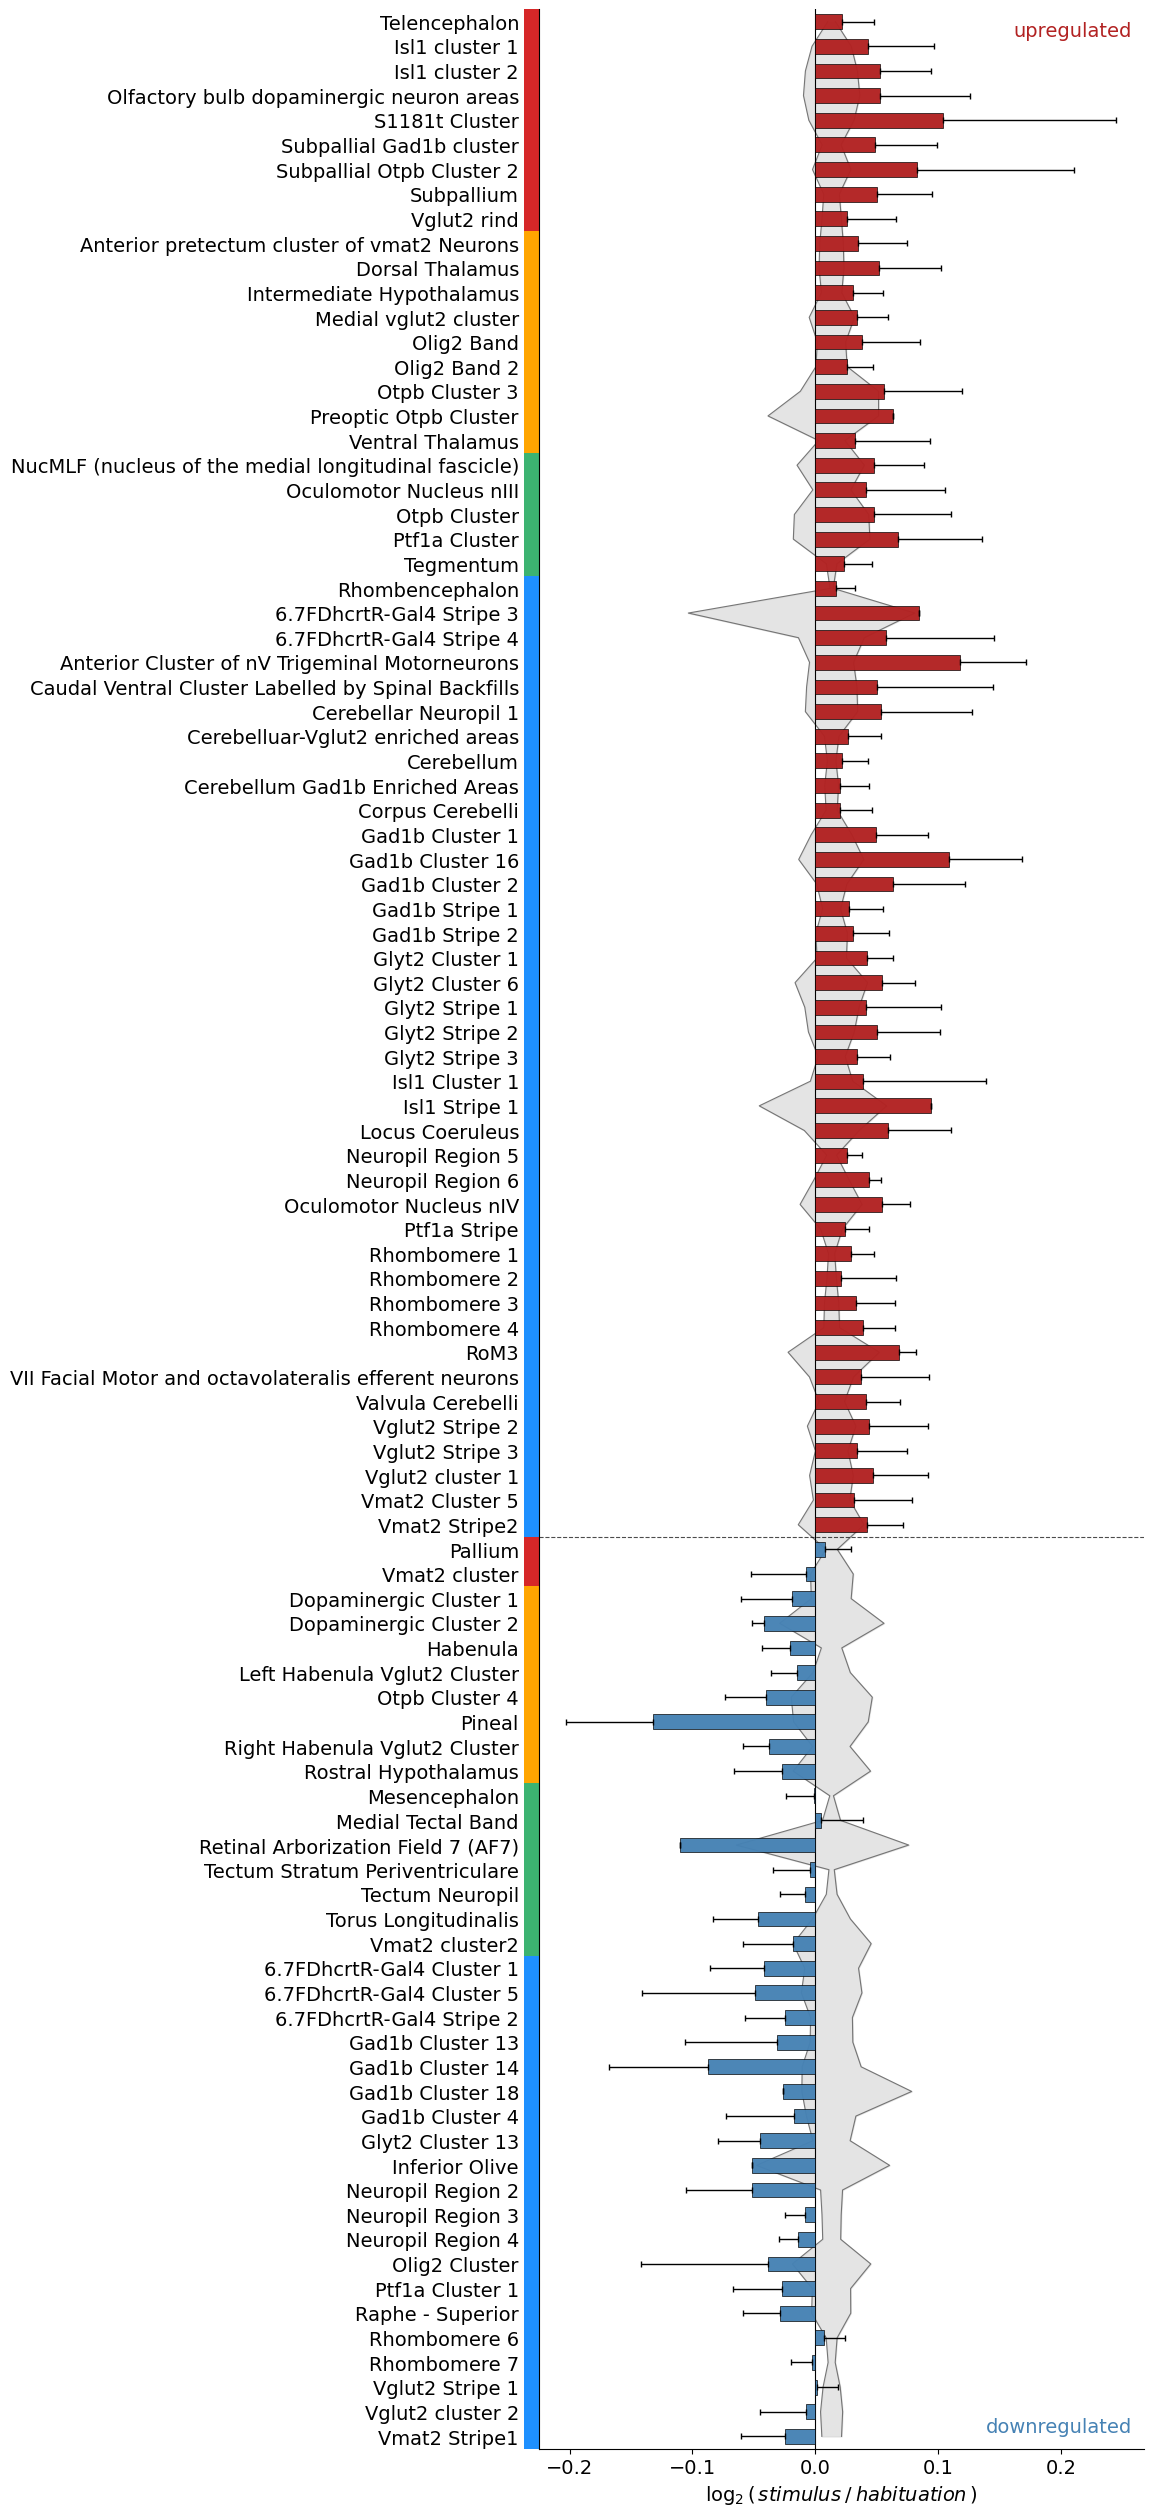

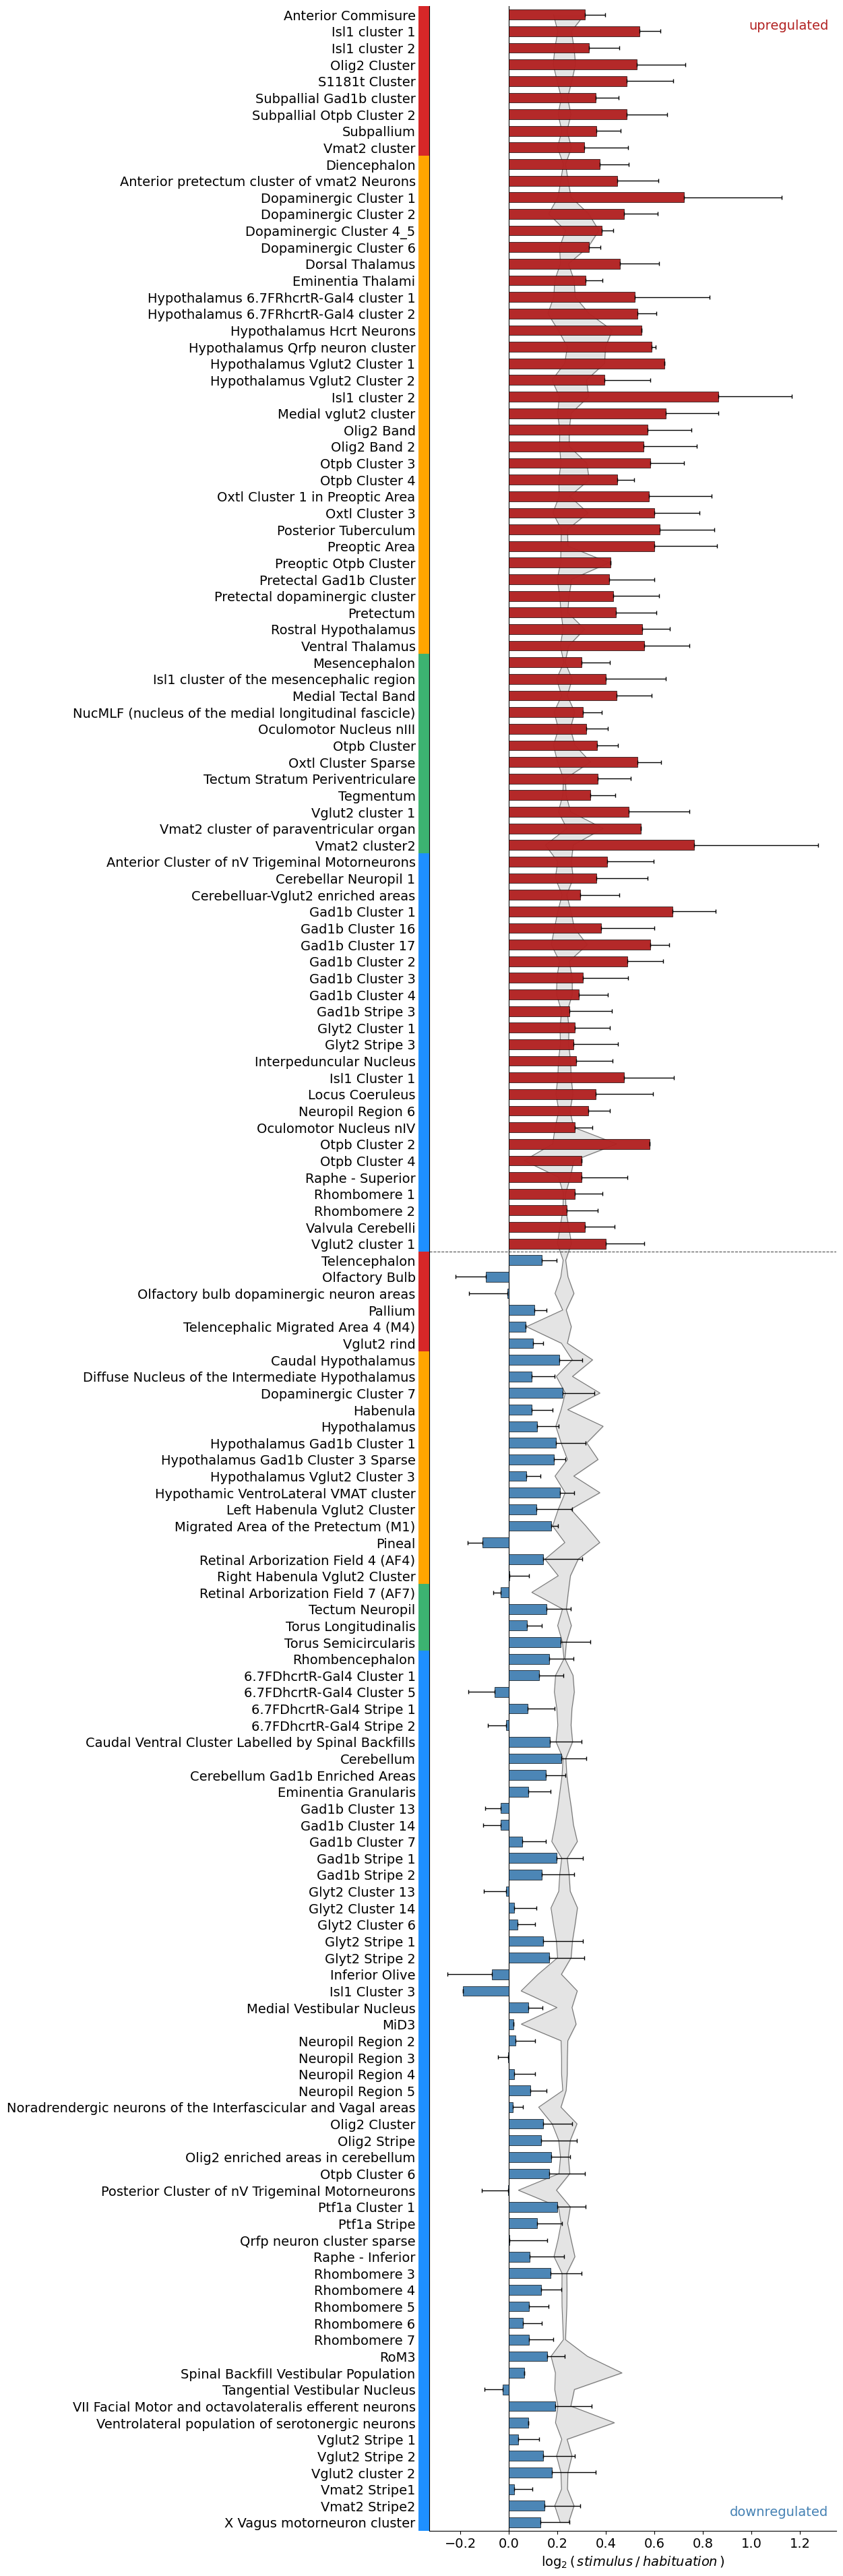

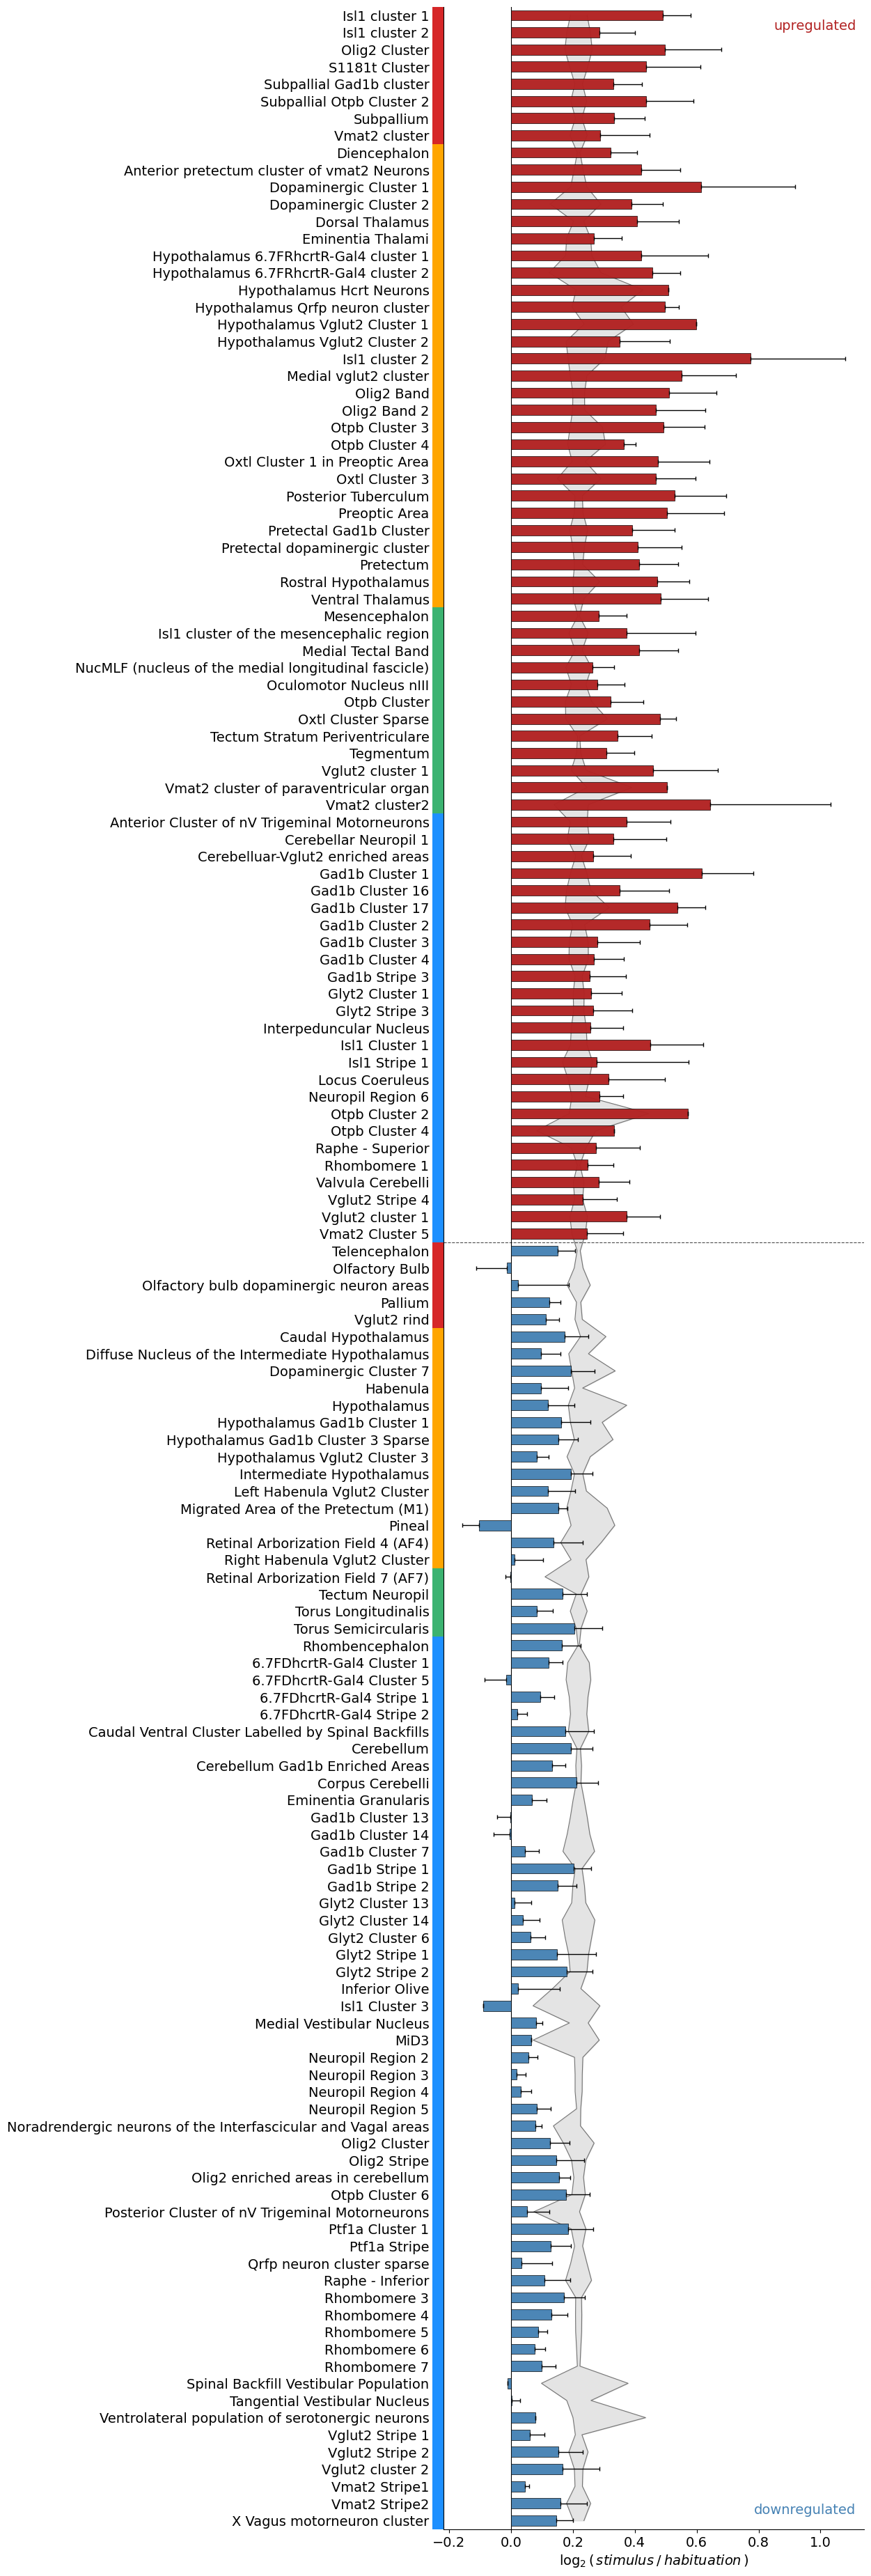

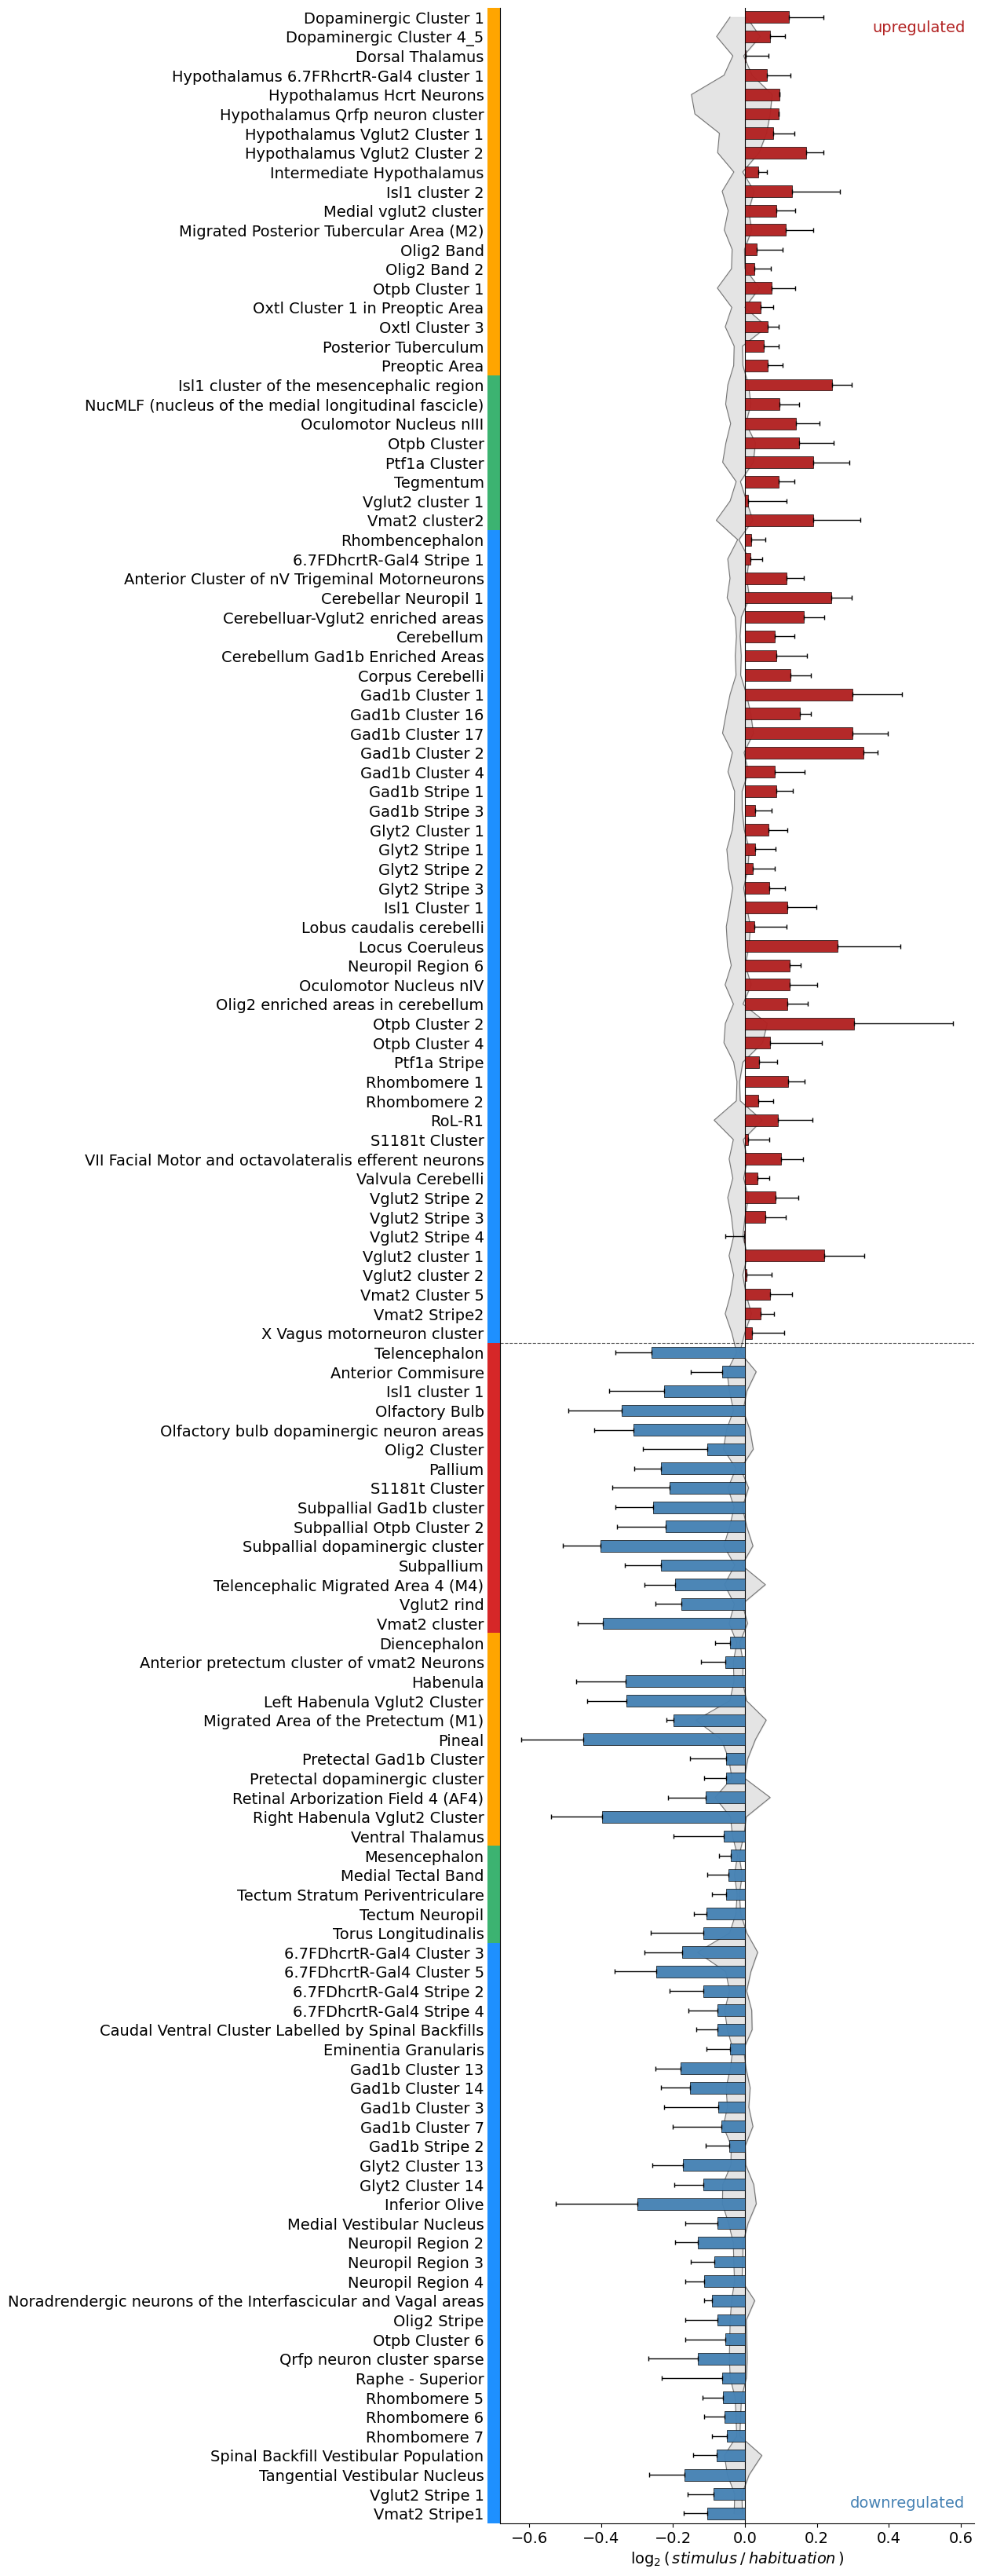

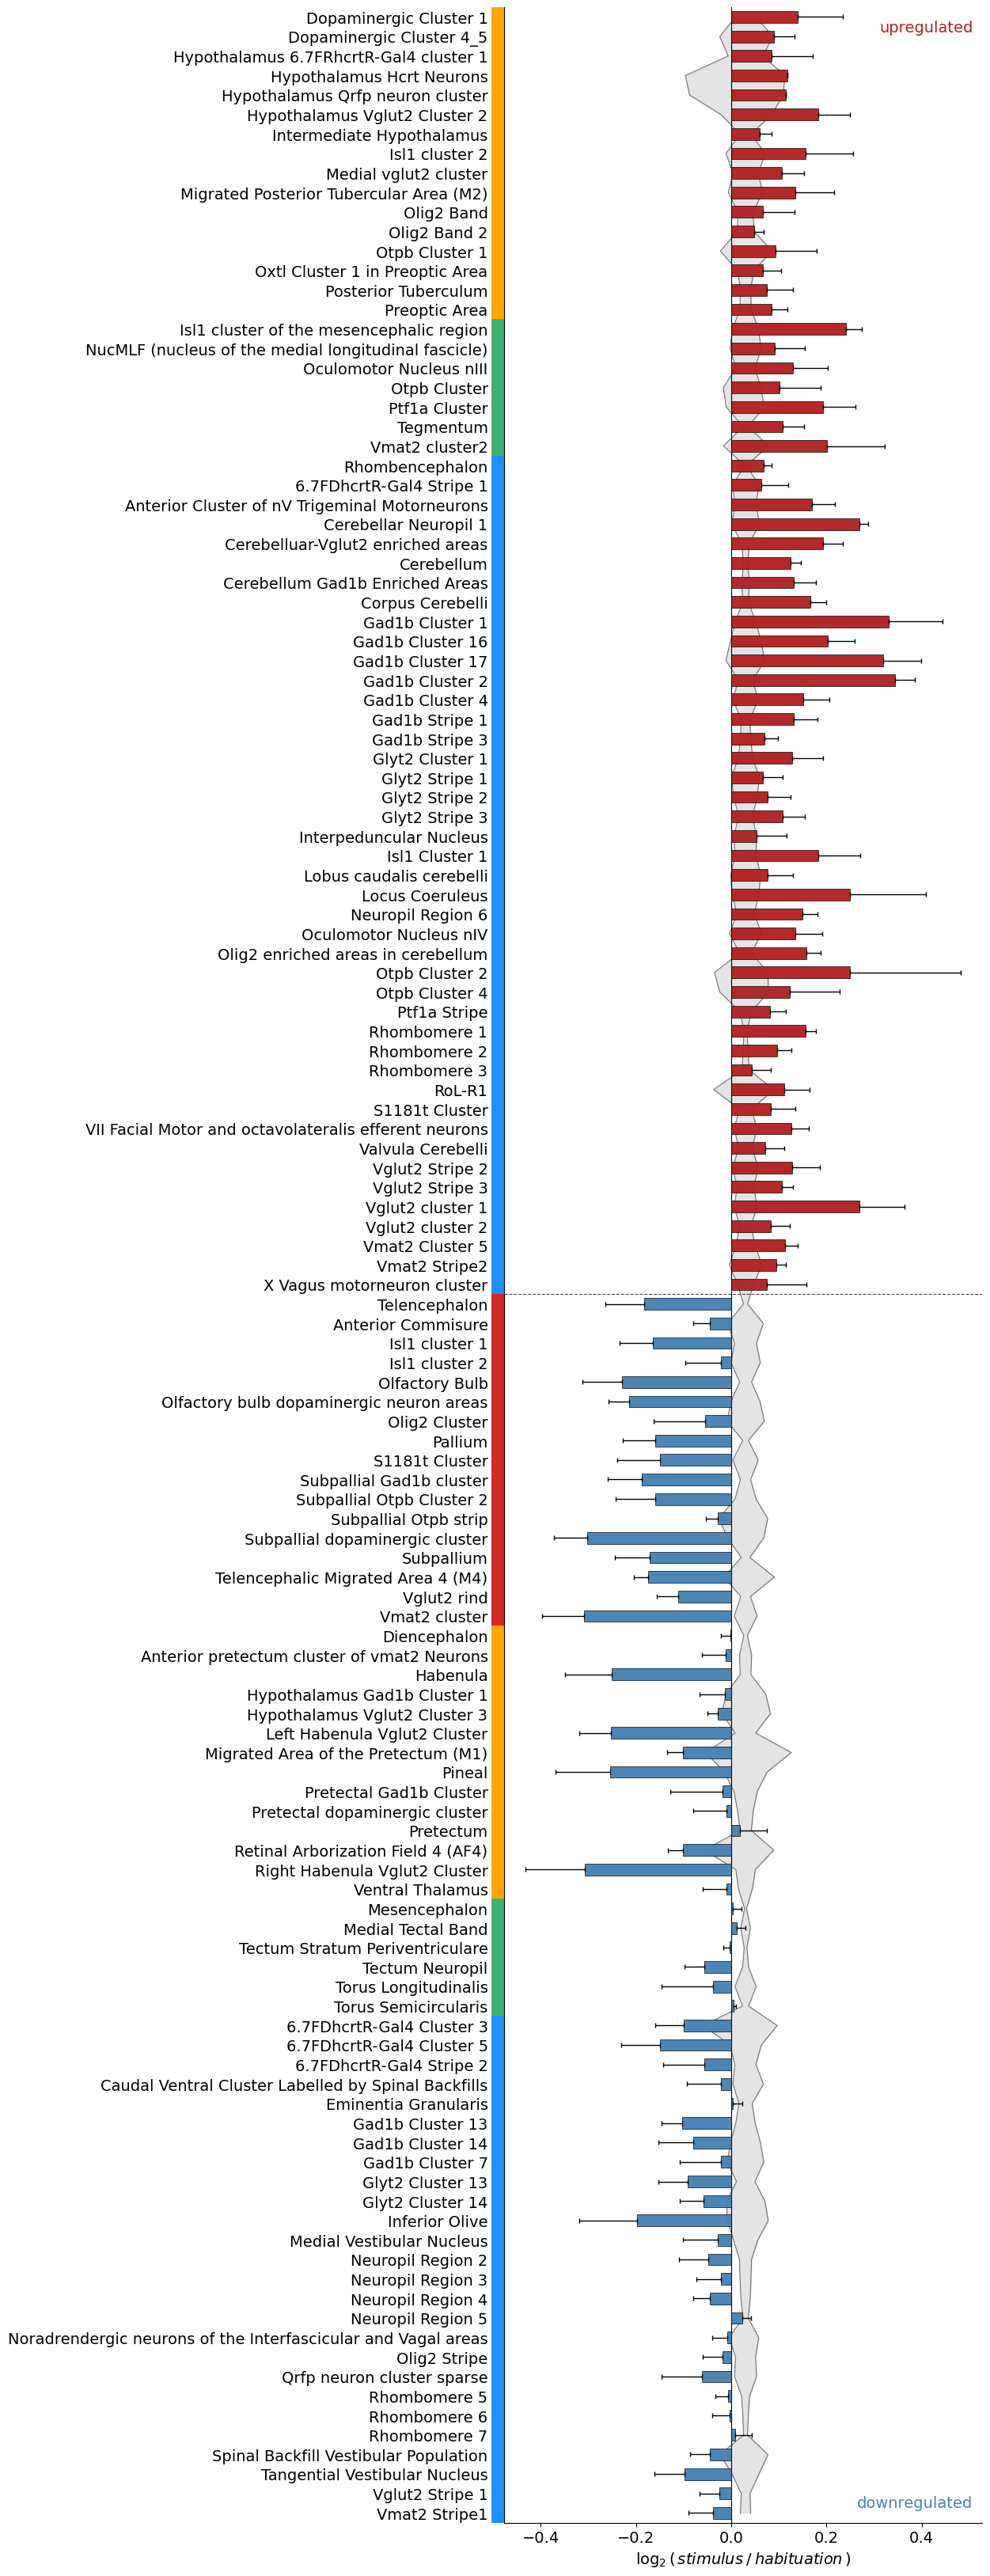

In [22]:
selection_tables = {}

for comp in compounds:
    for detrended in (False, True):
        tag = 'detrended' if detrended else 'raw'
        print(f'\n {comp} | {tag}')

        long = load_all_fish_and_compute_log2fc(root, comp, reference_brain, habituation, stimulus, detrended)
        res  = build_results_single_null_mean(long, group=comp, value_col='metric',
                                                min_cells=min_cells, n_boot=n_boot)

        xlabel = r'$\log_2(\,stimulus\:/\:habituation\,)$'  # \, for thin space in Latex math mode, \: for medium space
        plot_bootstrap_anatomical(
            res, selected_regions=curated, xlabel=xlabel,
            path_to_save=f'{outdir}/{comp}_log2fc_{tag}_{selected}_anatomical.pdf',
            draw_brain=draw_brain)

        # region selection table
        tbl = res[(res['upregulated']) | (res['downregulated'])].copy()
        if curated is not None:
            tbl = tbl.loc[tbl.index.intersection(curated)]
        tbl['division']   = [get_division(r) for r in tbl.index]
        tbl['short_name'] = [short_name_map.get(r, r) for r in tbl.index]
        tbl['direction']  = np.where(tbl['upregulated'], 'up', 'down')
        tbl = tbl.sort_values(by=['direction', 'division'])
        tbl.to_csv(f'{outdir}/{comp}_log2fc_{tag}_{selected}_regions.csv')
        selection_tables[(comp, tag)] = tbl
        print(f'  -> {len(tbl)} significant regions  ({int(tbl["upregulated"].sum())} up / '
              f'{int(tbl["downregulated"].sum())} down)')
